# How the graph prior samples its hyperparameters

*(Recreates the legacy `v1/1-prior_explore.ipynb`, refocused on the graph prior.)*

The `graph_scm` prior has no fixed hyperparameters: every dataset draw gets its own graph
size, edge-function shapes, categorical layouts, … all sampled through one object —
[`GlobalSampler`](../src/tabicl/prior/graph_lib/_base.py) — that lives on the dataset's
`Context`. Its behaviour is governed by `PriorConfig.meta_sampling_mode`.

The key idea is **named, hierarchical sampling**. Every quantity is drawn by name
(`"n_nodes"`, `"nn_width"`, `"gp_a"`, …) in one of three modes:

| mode | behaviour |
|------|-----------|
| `local` | independent draw every call |
| `global` | one draw per name, then cached — every call returns the same value |
| `meta` (default) | per name, first draw the parameters of a **Beta distribution** (once per dataset), then draw values from it — repeated calls are *correlated but not identical* |

Meta mode is what makes a dataset internally coherent (all its NN edge functions tend to
be similarly sized) while keeping datasets different from each other. This notebook makes
those distributions visible.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import trange

from tabicl.prior.graph_lib._config import PriorConfig
from tabicl.prior.graph_lib._base import Context
from tabicl.prior.graph_lib._properties import sample_categorical_sizes

np.random.seed(0)

/Users/elias/anaconda3/envs/tfm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The sampler API

A fresh `Context` = a fresh dataset draw. All prior components share its sampler and pull
named scalars from it:

In [2]:
ctx = Context(config=PriorConfig(), device="cpu")
s = ctx.sampler

print("randint  n_nodes [2, 32], log :", s.randint("n_nodes", 2, 33, use_log=True))
print("numerical gp_a [2, 20], log   :", f"{s.numerical('gp_a', 2.0, 20.0, use_log=True):.3f}")
print("choice   fct_type             :", s.choice("random_function_fct_type",
                                                  ["mlp", "tree", "disc", "lin", "quad", "gp", "em", "prod"]))
print("boolean  nn_start_act         :", s.boolean("nn_start_act"))

randint  n_nodes [2, 32], log : 4
numerical gp_a [2, 20], log   : 10.201
choice   fct_type             : gp
boolean  nn_start_act         : True


## The meta mechanism, made visible

In `meta` mode, each name gets a Beta distribution whose location and concentration are
drawn once per dataset. Below: six datasets (fresh `Context`s), each drawing the same
named quantity 400 times. Within a dataset the values cluster; across datasets the
cluster moves — the two-level structure of the prior.

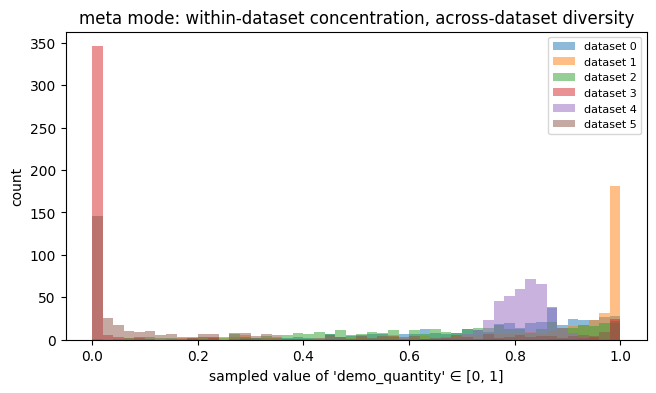

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4))
bins = np.linspace(0, 1, 51)
for d in range(6):
    ctx_d = Context(config=PriorConfig(), device="cpu")
    vals = [ctx_d.sampler.numerical("demo_quantity", 0.0, 1.0) for _ in range(400)]
    ax.hist(vals, bins=bins, alpha=0.5, label=f"dataset {d}")
ax.set_xlabel("sampled value of 'demo_quantity' ∈ [0, 1]")
ax.set_ylabel("count")
ax.set_title("meta mode: within-dataset concentration, across-dataset diversity")
ax.legend(fontsize=8)
plt.show()

## `PriorConfig.meta_sampling_mode`

The config can force every `meta` request down to `local` (fully i.i.d.) or up to
`global` (one value per name, frozen for the whole dataset). Same experiment, three
configs:

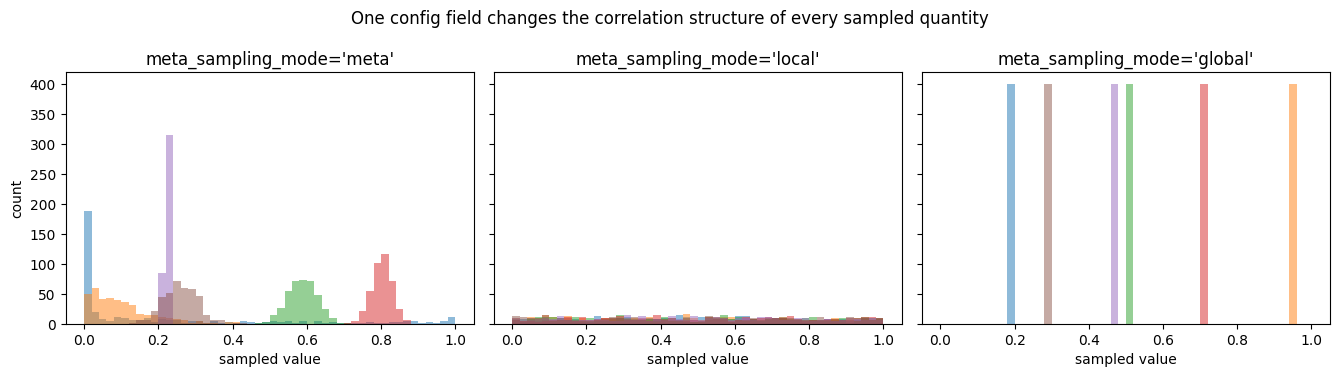

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharey=True)
for ax, mode in zip(axes, ["meta", "local", "global"]):
    cfg = PriorConfig(meta_sampling_mode=mode)
    for d in range(6):
        ctx_d = Context(config=cfg, device="cpu")
        vals = [ctx_d.sampler.numerical("demo_quantity", 0.0, 1.0) for _ in range(400)]
        ax.hist(vals, bins=bins, alpha=0.5)
    ax.set_title(f"meta_sampling_mode='{mode}'")
    ax.set_xlabel("sampled value")
axes[0].set_ylabel("count")
fig.suptitle("One config field changes the correlation structure of every sampled quantity")
fig.tight_layout()
plt.show()

## Marginal distributions of real prior quantities

Now sample the quantities the graph prior actually uses, one fresh `Context` (= dataset)
per draw, marginalising over the meta level. Names and ranges are taken verbatim from the
source: `"n_nodes"` from `RandomDataset`, `"nn_width"`/`"nn_n_layers"` from the NN edge
function, `"rt_n_trees"`/`"rt_depth"` from the tree function, `"gp_a"` from the GP
function (`graph_lib/_function.py`).

In [5]:
n_datasets = 2000
cfg = PriorConfig()

records = []
for _ in trange(n_datasets):
    c = Context(config=cfg, device="cpu").sampler
    records.append({
        "n_nodes": c.randint("n_nodes", cfg.min_n_nodes, cfg.max_n_nodes + 1, use_log=True),
        "nn_width": c.randint("nn_width", 1, 128, use_log=True),
        "nn_n_layers": c.randint("nn_n_layers", 1, 4, use_log=True),
        "rt_n_trees": c.numerical("rt_n_trees", 1, 128, use_log=True, use_int=True),
        "rt_depth": c.randint("rt_depth", 1, 8),
        "gp_a": c.numerical("gp_a", 2.0, 20.0, use_log=True),
    })
df = pd.DataFrame(records)
df.describe().round(2)

100%|██████████| 2000/2000 [00:00<00:00, 19489.35it/s]


,n_nodes,nn_width,nn_n_layers,rt_n_trees,rt_depth,gp_a
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,11.72,32.40,1.76,34.20,3.99,8.75
std,10.54,41.82,0.85,42.45,2.22,6.20
min,2.00,1.00,1.00,1.00,1.00,2.00
25%,3.00,2.00,1.00,3.00,2.00,3.21
50%,7.00,10.00,1.00,12.00,4.00,6.71
75%,19.00,49.00,3.00,54.00,6.00,13.67
max,32.00,127.00,3.00,128.00,7.00,20.00


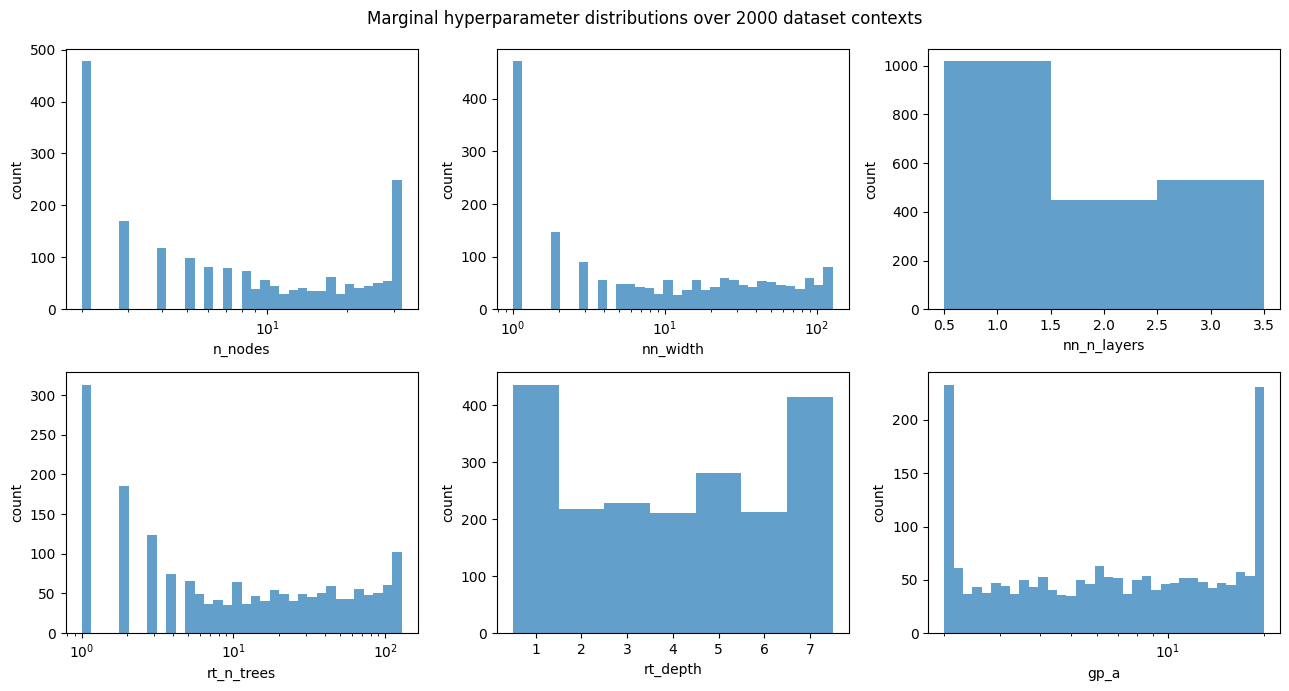

In [6]:
log_cols = {"n_nodes", "nn_width", "rt_n_trees", "gp_a"}
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), df.columns):
    vals = df[col].astype(float)
    if col in log_cols:
        b = np.logspace(np.log10(max(vals.min(), 1e-3)), np.log10(vals.max()), 35)
        ax.set_xscale("log")
    else:
        b = np.arange(vals.min(), vals.max() + 2) - 0.5
    ax.hist(vals, bins=b, color="tab:blue", alpha=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
fig.suptitle(f"Marginal hyperparameter distributions over {n_datasets} dataset contexts")
fig.tight_layout()
plt.show()

## Which edge-function family gets picked?

`RandomFunction` chooses a family per edge via `sampler.choice("random_function_fct_type", …)`
from the families allowed by `PriorConfig.fct_types` (`'default'` →
`mlp, tree, disc, lin, quad, gp, em, prod`). Because the choice is *meta-sampled* with
sparse random weights, a single dataset is dominated by a few families, while the mix is
roughly balanced across datasets:

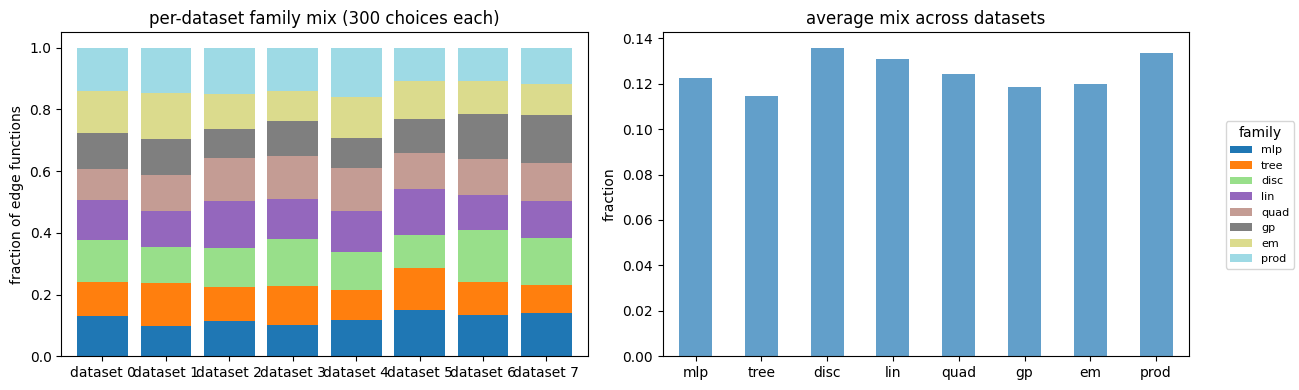

In [7]:
families = ["mlp", "tree", "disc", "lin", "quad", "gp", "em", "prod"]

per_dataset = []
for d in range(8):
    c = Context(config=cfg, device="cpu").sampler
    picks = [c.choice("random_function_fct_type", families) for _ in range(300)]
    per_dataset.append(pd.Series(picks).value_counts(normalize=True).reindex(families, fill_value=0.0))
mix = pd.DataFrame(per_dataset, index=[f"dataset {d}" for d in range(8)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
mix.plot(kind="bar", stacked=True, ax=ax1, colormap="tab20", rot=0, width=0.8, legend=False)
ax1.set_ylabel("fraction of edge functions")
ax1.set_title("per-dataset family mix (300 choices each)")
mix.mean(axis=0).plot(kind="bar", ax=ax2, color="tab:blue", alpha=0.7, rot=0)
ax2.set_title("average mix across datasets")
ax2.set_ylabel("fraction")
fig.legend(families, loc="center right", fontsize=8, title="family")
fig.tight_layout(rect=(0, 0, 0.93, 1))
plt.show()

## Categorical feature layout

Feature columns are made categorical by
[`sample_categorical_sizes`](../src/tabicl/prior/graph_lib/_properties.py): a random
fraction of the features gets a category count (log-sampled, partly meta, partly local),
the rest stay continuous (`cat_size = 0`).

100%|██████████| 1000/1000 [00:00<00:00, 15457.63it/s]


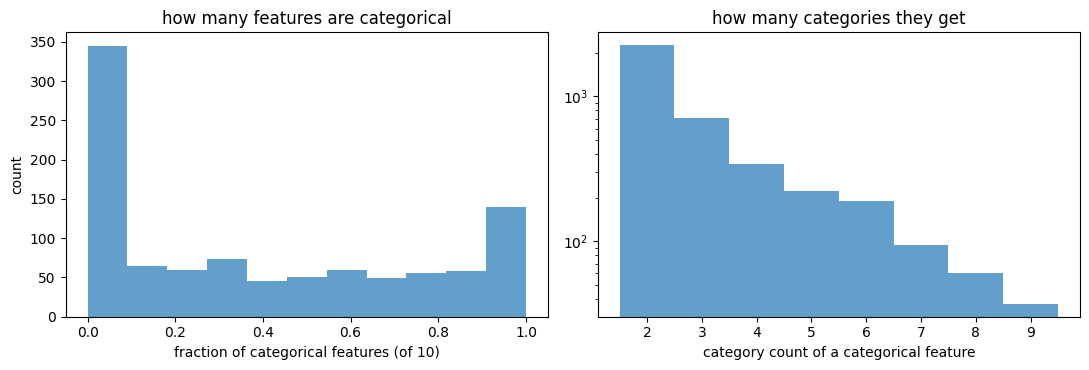

In [8]:
n_datasets_cat = 1000
n_features = 10

frac_categorical, cat_sizes_all = [], []
for _ in trange(n_datasets_cat):
    sizes = sample_categorical_sizes(n_features, Context(config=cfg, device="cpu"), max_cat_size=200)
    sizes = np.array(sizes)
    frac_categorical.append((sizes > 0).mean())
    cat_sizes_all.extend(sizes[sizes > 0].tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.hist(frac_categorical, bins=np.linspace(0, 1, 12), color="tab:blue", alpha=0.7)
ax1.set_xlabel(f"fraction of categorical features (of {n_features})")
ax1.set_ylabel("count")
ax1.set_title("how many features are categorical")
ax2.hist(cat_sizes_all, bins=np.arange(2, max(cat_sizes_all) + 2) - 0.5, color="tab:blue", alpha=0.7)
ax2.set_yscale("log")
ax2.set_xlabel("category count of a categorical feature")
ax2.set_title("how many categories they get")
fig.tight_layout()
plt.show()

## Recap

- The graph prior's hyperparameters all flow through `GlobalSampler`: **named** draws in
  `local` / `global` / `meta` mode, with `meta` (the default) giving per-dataset Beta
  distributions — coherent within a dataset, diverse across datasets.
- `PriorConfig.meta_sampling_mode` flips that correlation structure globally; other
  config fields (`min_n_nodes`/`max_n_nodes`, `fct_types`, `cat_modes`,
  `use_corrected_cat_sizes`, …) set the ranges and choice sets being sampled from.
- Edge-function families are meta-sampled too: individual datasets lean heavily on a few
  families, the ensemble covers all of them.

Next: `2-dag_gallery.ipynb` shows the graphs these hyperparameters produce;
`3-dag_density_analysis.ipynb` quantifies how the config knobs shape them.

In [9]:
print("done")

done
